In [9]:
# single imports cell
import numpy as np, imageio, os
from skimage import filters, morphology
from skimage.measure import label
import matplotlib.pyplot as plt
import napari
import tifffile

img_dir = r'../Images/Napari'


In [ ]:
# make a list called imgs that holds all your images
imgs = []
for i in range(1,4):
    p = os.path.join(img_dir, f'sample{i}.png')
    imgs.append(imageio.imread(p))

/var/folders/d9/l85dmfkd69n_zjnyz2wn1_480000gp/T/ipykernel_37676/867280166.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imgs.append(imageio.imread(p))


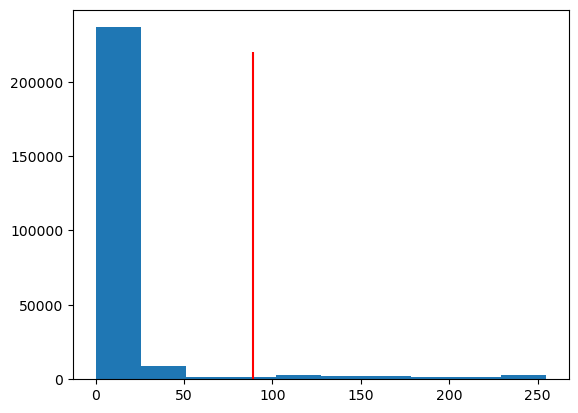

In [5]:
img = imgs[0]
plt.hist(img.ravel(), bins=10)
plt.vlines(filters.threshold_otsu(img), ymin=0, ymax=2.2e5, colors='r')

In [27]:
# make a list called masks that holds masks for each image
otsu_factor = 0.3 # use the position of the red line to estimate an otsu multiplier

masks = []
for i in range(3):
    img = imgs[i]
    th = filters.threshold_otsu(img) * otsu_factor
    bw = img > th
    bw = morphology.remove_small_objects(bw, min_size=25) # prevents masks from being created around small patches of noise
    masks.append(bw)


In [ ]:
# View images in Napari and use brush and eraser tools to manually correct labels
# To split labels, erase a line at the border and fill with the paint can
# Try increasing the contour above 0 to view the boundaries of the masks

img_number = 0

viewer = napari.Viewer()
viewer.add_image(imgs[img_number], name='image')
viewer.add_labels(label(masks[img_number]).astype('uint16'), name='labels')
print('Napari launched')
napari.run()

Napari launched


In [ ]:
# Find the max label number.  This is useful when you need to manually add new masks
viewer.layers['labels'].data.max()

np.uint16(37)

In [ ]:
# Save current 'labels' layer to your img_dir

labels = viewer.layers["labels"].data

p = os.path.join(img_dir, f'edited_labels{img_number + 1}.tif')
tifffile.imwrite(p, labels.astype("uint16"))


Rerun the code above with different parameters to get a sense for how they affect the outcome:
1. Try commenting out the remove_small_objects line
2. Try setting the otsu_factor to 0.3 or 1.2